In [1]:
from datetime import datetime
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

import lightgbm as lgb

import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from sklearn.calibration import calibration_curve

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", module="lgb")

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("lgbm: "+lgb.__version__)

pandas: 3.0.1
numpy: 2.4.3
lgbm: 4.7.0


In [2]:
df = pd.read_csv('data/shot_probs_data.csv')
df.head()

,distance,angle,shot_type_numeric,shot_type,is_behind_backboard,set_name,is_made
0,0.187613,0.195018,0,JUMPER,0,train,0
1,0.029004,0.524437,1,LAYUP,0,train,0
2,0.115727,0.422763,0,JUMPER,0,train,1
3,0.256781,0.472390,0,JUMPER,0,train,1
4,0.109662,0.224862,0,JUMPER,0,train,1


In [3]:
def make_dataset(df:pd.DataFrame, set_name:str):
    dff = df.loc[df['set_name']==set_name].drop(['set_name','is_made','shot_type','shot_type_numeric'],axis=1).reset_index(drop=True)
    target = df.loc[df['set_name']==set_name]['is_made'].values
    shot_name_vals = df.loc[df['set_name']==set_name]['shot_type'].values
    return dff, target, shot_name_vals

X_train_mm, y_train, shot_train = make_dataset(df, 'train')
X_val_mm, y_val, shot_val = make_dataset(df, 'val')
X_query_mm, y_query, shot_query = make_dataset(df, 'query')
X_test_mm, y_test, shot_test = make_dataset(df, 'test')

print(X_train_mm.shape, X_val_mm.shape, X_query_mm.shape, X_test_mm.shape)

(1612163, 3) (690928, 3) (493520, 3) (493519, 3)


In [4]:
X_train_mm.head()

,distance,angle,is_behind_backboard
0,0.187613,0.195018,0
1,0.029004,0.524437,0
2,0.115727,0.422763,0
3,0.256781,0.472390,0
4,0.109662,0.224862,0


In [5]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

def score_model(model, X, y, model_name=None):
    if model_name == 'nn':
        preds = model.predict_proba(X)
    else:
        preds = model.predict_proba(X)[:,1]
    loss, auc, acc = compute_scores(y, preds)
    print(f"Log Loss: {loss:.4f}, AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    return None

In [6]:
def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze, label="_nolegend_")

In [7]:
# lgbm params
lgbm_params = {
    'num_leaves': [4, 7, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [100, 200, 300],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0, 0.25, 0.75],
    'min_split_gain': [0.005, 0.01, 0.1],
}
lg_grid = ParameterGrid(lgbm_params)

best_score = float('inf')
best_params = None
start = datetime.now()
for i, params in enumerate(lg_grid):
    model = lgb.LGBMClassifier(
        **params,
        n_estimators=3000,
        subsample=0.75,
        extra_trees=True,
        max_bin=512,     
        subsample_freq=1,
        n_jobs=-1,
        monotone_constraints=(-1, 0, 0),
        monotone_constraints_method='advanced',
        random_state=RANDOM_SEED,
        verbosity=-1
    )
    callbacks = [lgb.early_stopping(stopping_rounds=200, verbose=False)]
    
    model.fit(
        X_train_mm, y_train,
        eval_X=(X_train_mm, X_val_mm),
        eval_y=(y_train, y_val),
        eval_metric='logloss',
        callbacks=callbacks
    )
    current_score = model.best_score_['valid_1']['binary_logloss']

    if current_score < best_score:
        best_score = current_score
        best_params = params
        best_model = model

end = datetime.now()
print('fit time: '+str(round((end - start).total_seconds()/60,2)))
print(best_params)
print(best_score)
print(best_model.best_iteration_)

fit time: 834.93
{'learning_rate': 0.1, 'min_child_samples': 200, 'min_split_gain': 0.005, 'num_leaves': 7, 'reg_alpha': 0, 'reg_lambda': 10}
0.6539140288665127
3000


In [8]:
best_model

,boosting_type,'gbdt'
,num_leaves,7
,max_depth,-1
,learning_rate,0.1
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.005
,min_child_weight,0.001
,min_child_samples,200


In [9]:
score_model(best_model, X_train_mm, y_train)
score_model(best_model, X_val_mm, y_val)

Log Loss: 0.6539, AUC: 0.6350, Accuracy: 0.6239
Log Loss: 0.6539, AUC: 0.6349, Accuracy: 0.6240


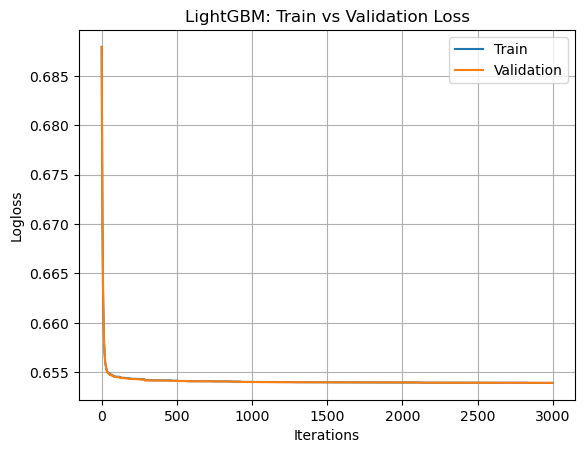

In [10]:
results = best_model.evals_result_
train_loss = results['valid_0']['binary_logloss']
val_loss = results['valid_1']['binary_logloss']
fig, ax = plt.subplots()
ax.plot(train_loss, label='Train')
ax.plot(val_loss, label='Validation')
ax.set_xlabel('Iterations')
ax.set_ylabel('Logloss')
ax.set_title('LightGBM: Train vs Validation Loss')
ax.legend()
ax.grid(True)

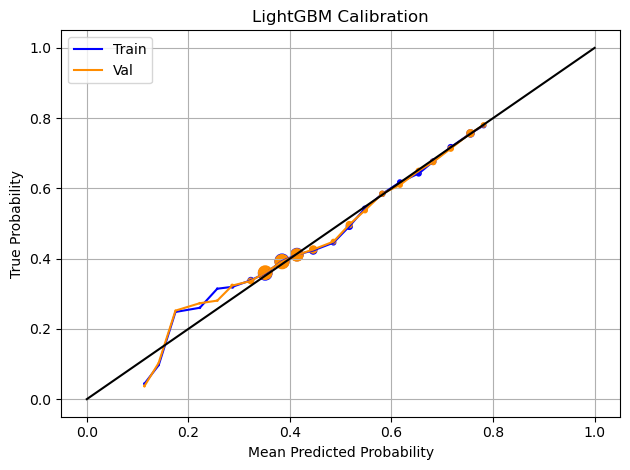

In [11]:
train_probs = best_model.predict_proba(X_train_mm)[:,1]
val_probs = best_model.predict_proba(X_val_mm)[:,1]
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_val, val_probs, "Val", "darkorange")
plt.title("LightGBM Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Val"], loc="upper left")
plt.plot([0, 1], [0, 1], color='black')
plt.grid(True)
plt.tight_layout()

In [12]:
best_lgbm = lgb.LGBMClassifier(
    **best_params,
    n_estimators=best_model.best_iteration_,
    subsample=0.75,
    extra_trees=True,
    max_bin=512,
    subsample_freq=1,
    n_jobs=-1,
    monotone_constraints=(-1, 0, 0),
    monotone_constraints_method='advanced',
    random_state=RANDOM_SEED,
    verbosity=-1
)
X_full_mm = np.concatenate((X_train_mm, X_val_mm))
y_full = np.concatenate((y_train, y_val))
 
best_lgbm.fit(
    X_full_mm, y_full
)
score_model(best_lgbm, X_query_mm, y_query)
score_model(best_lgbm, X_test_mm, y_test)

Log Loss: 0.6542, AUC: 0.6346, Accuracy: 0.6234
Log Loss: 0.6541, AUC: 0.6342, Accuracy: 0.6235
